In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
df = pd.read_csv("/content/final_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (38081, 6)

Columns: ['Statement', 'Web', 'Category', 'Label', 'Month-Year', 'Year']

First 5 Rows:


,Statement,Web,Category,Label,Month-Year,Year
0,Heritage Conservation Committee approves const...,THEPRINT,POLITICS,TRUE,Aug-04,2004
1,Neta Profiling  Party Wise,FACTLY,ELECTION,TRUE,Dec-11,2011
2,Quotable Quotes  The best of 2011,FACTLY,POLITICS,TRUE,Dec-11,2011
3,Open Letter from Anna Hazare to all Indians,FACTLY,POLITICS,TRUE,Oct-11,2011
4,"Kaun Banega Cr000,000,000,000repati!",FACTLY,COVID-19,TRUE,Jul-11,2011


In [3]:
# Basic info
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['Label'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38081 entries, 0 to 38080
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Statement   38081 non-null  object
 1   Web         38081 non-null  object
 2   Category    38081 non-null  object
 3   Label       38081 non-null  object
 4   Month-Year  38081 non-null  object
 5   Year        38081 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.7+ MB

Missing Values:
Statement     0
Web           0
Category      0
Label         0
Month-Year    0
Year          0
dtype: int64

Label Distribution:
Label
TRUE    37789
Fake      292
Name: count, dtype: int64


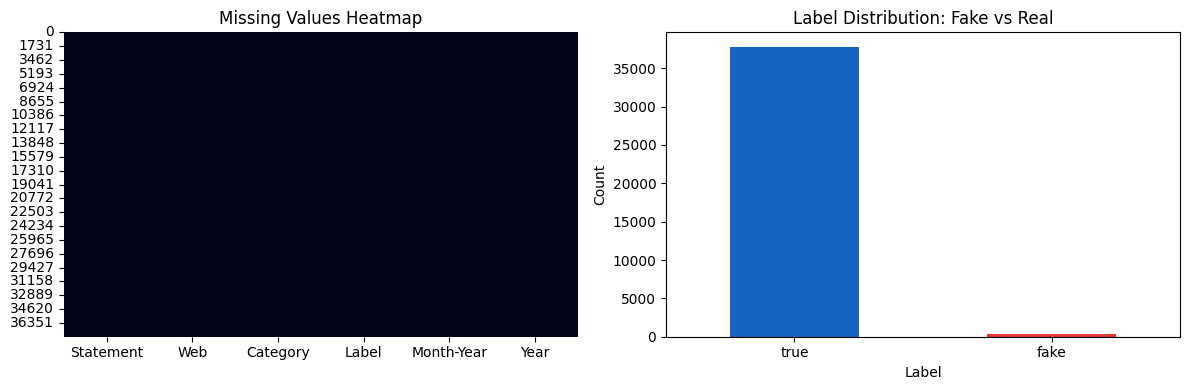

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Missing values heatmap
sns.heatmap(df.isnull(), cbar=False, ax=axes[0])
axes[0].set_title("Missing Values Heatmap")

# Label distribution
df['Label'].str.strip().str.lower().value_counts().plot(
    kind='bar', ax=axes[1], color=['#1565C0', '#E53935']
)
axes[1].set_title("Label Distribution: Fake vs Real")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [5]:
# Drop rows with missing values
df.dropna(inplace=True)

# Normalize label column
df['Label'] = df['Label'].str.strip().str.lower()

print("Unique Labels:", df['Label'].unique())
print("Class Distribution:\n", df['Label'].value_counts())

# Text cleaning function
def clean_text(text):
    """Lowercase, remove non-alphabetic characters, and strip extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning
df['clean_text'] = df['Statement'].apply(clean_text)

print("\nSample cleaned text:")
print(df[['Statement', 'clean_text']].head(3))

Unique Labels: ['true' 'fake']
Class Distribution:
 Label
true    37789
fake      292
Name: count, dtype: int64

Sample cleaned text:
                                           Statement  \
0  Heritage Conservation Committee approves const...   
1                        Neta Profiling  Party Wise   
2                 Quotable Quotes  The best of 2011   

                                          clean_text  
0  heritage conservation committee approves const...  
1                          neta profiling party wise  
2                        quotable quotes the best of  


In [6]:
X = df['clean_text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures balanced class split
)

print("Training size:", X_train.shape[0])
print("Testing size :", X_test.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts())

Training size: 30464
Testing size : 7617

Training class distribution:
Label
true    30230
fake      234
Name: count, dtype: int64


In [7]:
# Each model is wrapped in a Pipeline:
#   Step 1 - TF-IDF Vectorizer (bigrams, top 5000 features, English stopwords removed)
#   Step 2 - Classifier

TFIDF_PARAMS = dict(max_features=5000, ngram_range=(1, 2), stop_words='english')

models = {
    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('model', LogisticRegression(max_iter=200, class_weight='balanced', C=2))
    ]),
    "SVM": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('model', LinearSVC(C=1.5))
    ]),
    "Decision Tree": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('model', DecisionTreeClassifier())
    ]),
    "KNN": Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']


In [8]:
results = {"Model": [], "Accuracy": [], "Precision": [], "Recall": [], "F1 Score": []}

for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='fake')
    rec  = recall_score(y_test, y_pred, pos_label='fake')
    f1   = f1_score(y_test, y_pred, pos_label='fake')

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results["Model"].append(name)
    results["Accuracy"].append(acc)
    results["Precision"].append(prec)
    results["Recall"].append(rec)
    results["F1 Score"].append(f1)

results_df = pd.DataFrame(results)
print("\n✅ All models trained and evaluated")


  Logistic Regression
Accuracy : 0.9949
Precision: 0.6234
Recall   : 0.8276
F1 Score : 0.7111

Classification Report:
              precision    recall  f1-score   support

        fake       0.62      0.83      0.71        58
        true       1.00      1.00      1.00      7559

    accuracy                           0.99      7617
   macro avg       0.81      0.91      0.85      7617
weighted avg       1.00      0.99      1.00      7617


  SVM
Accuracy : 0.9975
Precision: 0.9149
Recall   : 0.7414
F1 Score : 0.8190

Classification Report:
              precision    recall  f1-score   support

        fake       0.91      0.74      0.82        58
        true       1.00      1.00      1.00      7559

    accuracy                           1.00      7617
   macro avg       0.96      0.87      0.91      7617
weighted avg       1.00      1.00      1.00      7617


  Decision Tree
Accuracy : 0.9959
Precision: 0.7288
Recall   : 0.7414
F1 Score : 0.7350

Classification Report:
           

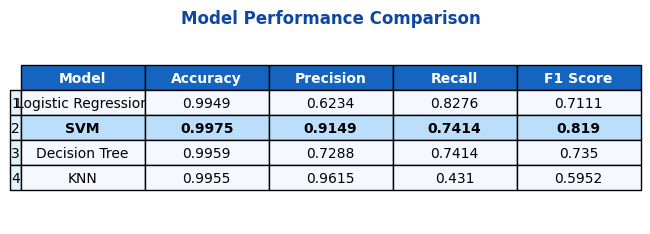

In [21]:
import matplotlib.pyplot as plt

styled_df = results_df.copy()

# Index from 1
styled_df.index = styled_df.index + 1

# Round values
styled_df.iloc[:, 1:] = styled_df.iloc[:, 1:].round(4)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')

table = ax.table(
    cellText=styled_df.values,
    colLabels=styled_df.columns,
    rowLabels=styled_df.index,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# 🎨 BLUE THEME STYLING
for (row, col), cell in table.get_celld().items():

    # Header
    if row == 0:
        cell.set_facecolor('#1565C0')   # deep blue
        cell.set_text_props(color='white', weight='bold')

    # Index column
    elif col == -1:
        cell.set_facecolor('#E3F2FD')   # light blue

    # Highlight SVM row
    elif row == 2:
        cell.set_facecolor('#BBDEFB')   # medium light blue
        cell.set_text_props(weight='bold')

    # Other cells
    else:
        cell.set_facecolor('#F5F9FF')   # very light blue

plt.title("Model Performance Comparison", fontsize=12, weight='bold', color='#0D47A1')
plt.show()

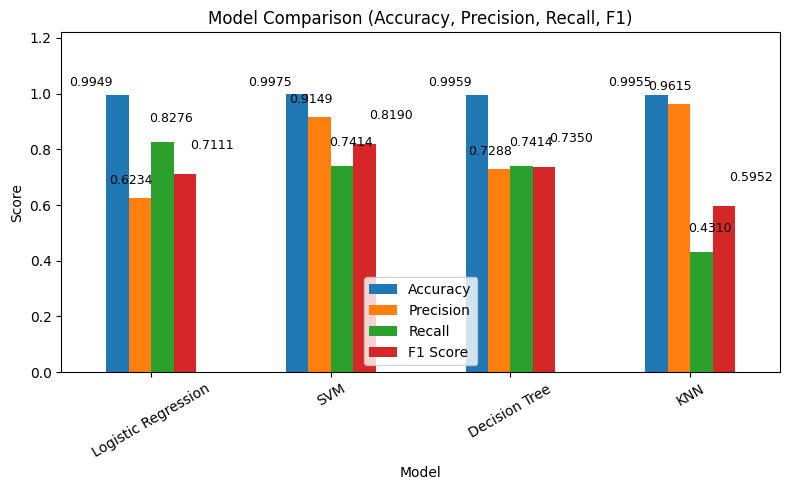

In [17]:
ax = results_df.set_index("Model").plot(kind='bar', figsize=(8,5))

plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.ylabel("Score")
plt.xticks(rotation=30)

for i, container in enumerate(ax.containers):
    for j, bar in enumerate(container):
        height = bar.get_height()

        # STRONG horizontal separation
        shift = (i - 1.5) * 0.10

        # STRONG vertical stagger (fixed per metric)
        vertical_offsets = [0.02, 0.04, 0.06, 0.08]
        v_shift = vertical_offsets[i]

        ax.text(
            bar.get_x() + bar.get_width()/2 + shift,
            height + v_shift,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

ax.set_ylim(0, 1.22)

plt.tight_layout()
plt.show()

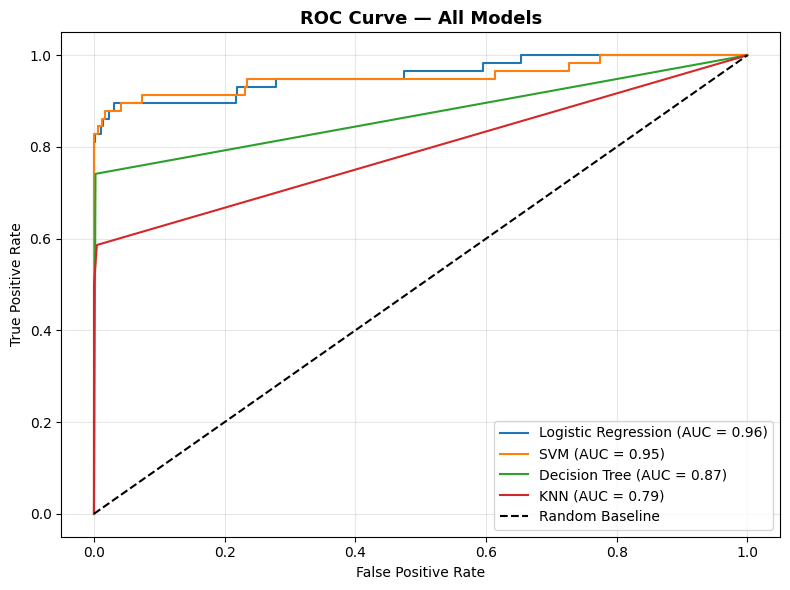

In [19]:
# Binary target: 'fake' = 1, 'true' = 0
y_test_binary = (y_test == 'fake').astype(int)

plt.figure(figsize=(8, 6))

for name, model in models.items():
    clf = model.named_steps['model']

    if hasattr(clf, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        class_index = list(clf.classes_).index('fake')
        y_scores = model.predict_proba(X_test)[:, class_index]

    fpr, tpr, _ = roc_curve(y_test_binary, y_scores)
    roc_auc = auc(fpr, tpr)

    # Fix inverted curve (if AUC < 0.5)
    if roc_auc < 0.5:
        y_scores = -y_scores
        fpr, tpr, _ = roc_curve(y_test_binary, y_scores)
        roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models", fontsize=13, weight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

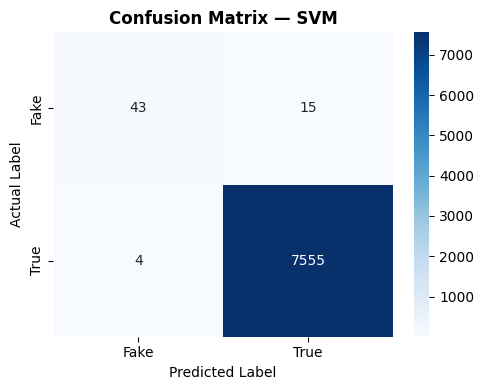


Confusion Matrix (raw):
 [[  43   15]
 [   4 7555]]


In [12]:
best_model_name = "SVM"
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=['fake', 'true'])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix — {best_model_name}", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (raw):\n", cm)

In [13]:
joblib.dump(best_model, "fake_news_model.pkl")
print(f"✅ Best model ({best_model_name}) saved as 'fake_news_model.pkl'")

✅ Best model (SVM) saved as 'fake_news_model.pkl'


In [16]:
def predict_news(text: str) -> str:
    """
    Predicts whether a news statement is 'fake' or 'true'.

    Parameters:
        text (str): Raw news statement.

    Returns:
        str: Predicted label ('fake' or 'true').
    """
    cleaned = clean_text(text)
    prediction = best_model.predict([cleaned])[0]
    return prediction


# ── Test Examples ─────────────────────────────────────────────────────────────
test_samples = [
    "Government launches new scheme for farmers",
    "Breaking news: Aliens have landed in Washington DC!",
    "New government policy announced to improve healthcare"
]

print("Sample Predictions:")
print("-" * 55)
for sample in test_samples:
    label = predict_news(sample)
    print(f"  '{sample[:45]}...' → {label.upper()}")

Sample Predictions:
-------------------------------------------------------
  'Government launches new scheme for farmers...' → TRUE
  'Breaking news: Aliens have landed in Washingt...' → TRUE
  'New government policy announced to improve he...' → TRUE
